## **CPSC 368 Project Group 6 Python File**
### ***How do danceability and speechiness of a song relate to Spotify chart popularity and sustainability?***

In [9]:
import pandas as pd
import oracledb
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
import statsmodels.api as sm
import warnings

#### **Oracle DB Connection and SQL File Insertion**

In [ ]:
dsn = oracledb.makedsn("localhost", 1522, service_name="stu")

# change user and password
connection = oracledb.connect(
    user="ora_emmaoh",
    password="a18182394",
    dsn=dsn
)

cur = connection.cursor()

# read the SQL file
with open("insert_data_v3.sql", "r", encoding="utf-8") as file:
    sql_script = file.read()

# split SQL statements
statements = sql_script.split(";")

# execute each statement and throw error if there is a sql statement error
for i, stmt in enumerate(statements, start=1):
    stmt = stmt.strip()
    if stmt:
        try:
            cur.execute(stmt)
        except Exception as e:
            print(f"Skipping error at statement {i}: {e} at {stmt}")

connection.commit()

In [4]:
cur.execute("""
SELECT table_name 
FROM user_tables
ORDER BY table_name
""")

tables = [row[0] for row in cur.fetchall()]

#### **Research Question Results**
#### 1. *How do danceability and speechiness levels vary between songs with above-average and below-average Spotify popularity scores among the top 100 songs within the year?*

##### 1.1. Danceability Query

In [10]:
#query for danceability
warnings.filterwarnings("ignore", category=UserWarning)

rq1_danceability = """
SELECT 
    popularity_category,
    AVG(danceability) AS avg_danceability
FROM (
    SELECT 
        s.track_id,
        s.danceability,
        s.track_popularity,
        CASE
            WHEN s.track_popularity <= (
                SELECT AVG(track_popularity) 
                FROM (
                    SELECT track_id, AVG(streams) AS avg_streams
                    FROM CHARTS
                    GROUP BY track_id
                    ORDER BY AVG(streams) DESC
                    FETCH FIRST 100 ROWS ONLY
                ) TOP_100
                JOIN SPOTIFY_SONGS ss ON TOP_100.track_id = ss.track_id
            ) THEN 'Below Average Popularity'
            ELSE 'Above Average Popularity'
        END AS popularity_category
    FROM (
        SELECT track_id, AVG(streams) AS avg_streams
        FROM CHARTS
        GROUP BY track_id
        ORDER BY AVG(streams) DESC
        FETCH FIRST 100 ROWS ONLY
    ) TOP_100
    JOIN SPOTIFY_SONGS s ON TOP_100.track_id = s.track_id
)
GROUP BY popularity_category
"""

rq1_danceability_df = pd.read_sql(rq1_danceability, connection)
rq1_danceability_df.head()

,POPULARITY_CATEGORY,AVG_DANCEABILITY
0,Above Average Popularity,0.702500
1,Below Average Popularity,0.688813


##### 1.2. Speechiness Query

In [11]:
#query for speechiness
warnings.filterwarnings("ignore", category=UserWarning)

rq1_speechiness = """
SELECT 
    popularity_category,
    AVG(speechiness) AS avg_speechiness
FROM (
    SELECT 
        s.track_id,
        s.speechiness,
        s.track_popularity,
        CASE
            WHEN s.track_popularity <= (
                SELECT AVG(track_popularity) 
                FROM (
                    SELECT track_id, AVG(streams) AS avg_streams
                    FROM CHARTS
                    GROUP BY track_id
                    ORDER BY AVG(streams) DESC
                    FETCH FIRST 100 ROWS ONLY
                ) TOP_100
                JOIN SPOTIFY_SONGS ss ON TOP_100.track_id = ss.track_id
            ) THEN 'Below Average Popularity'
            ELSE 'Above Average Popularity'
        END AS popularity_category
    FROM (
        SELECT track_id, AVG(streams) AS avg_streams
        FROM CHARTS
        GROUP BY track_id
        ORDER BY AVG(streams) DESC
        FETCH FIRST 100 ROWS ONLY
    ) TOP_100
    JOIN SPOTIFY_SONGS s ON TOP_100.track_id = s.track_id
)
GROUP BY popularity_category
"""

rq1_speechiness_df = pd.read_sql(rq1_speechiness, connection)
rq1_speechiness_df.head()

,POPULARITY_CATEGORY,AVG_SPEECHINESS
0,Above Average Popularity,0.134822
1,Below Average Popularity,0.128941


##### 1.3. Danceability Visualization

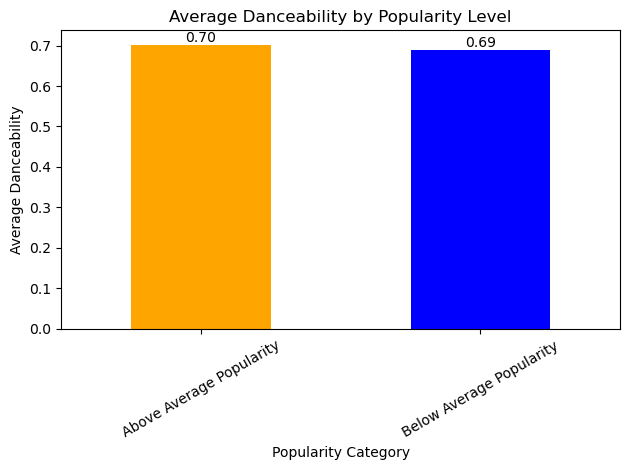

In [13]:
rq1_danceability_df = rq1_danceability_df.sort_values("POPULARITY_CATEGORY")
rq1_1 = rq1_danceability_df.plot(
  x="POPULARITY_CATEGORY",
  y="AVG_DANCEABILITY", 
  kind="bar",
  color=["orange", "blue"],
  legend=False
)

for container in rq1_1.containers:
    rq1_1.bar_label(container, fmt="%.2f")

plt.title("Average Danceability by Popularity Level")
plt.xticks(rotation=30)
plt.xlabel("Popularity Category")
plt.ylabel("Average Danceability")
plt.tight_layout()
plt.show()

##### 1.4. Speechiness Visualization

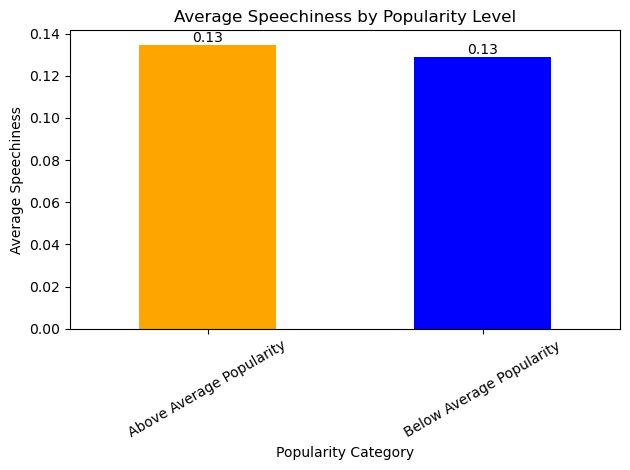

In [14]:
rq1_speechiness_df = rq1_speechiness_df.sort_values("POPULARITY_CATEGORY")
rq1_2 = rq1_speechiness_df.plot(
  x="POPULARITY_CATEGORY",
  y="AVG_SPEECHINESS", 
  kind="bar",
  color=["orange", "blue"],
  legend=False
)

for container in rq1_2.containers:
    rq1_2.bar_label(container, fmt="%.2f")

plt.title("Average Speechiness by Popularity Level")
plt.xticks(rotation=30)
plt.xlabel("Popularity Category")
plt.ylabel("Average Speechiness")
plt.tight_layout()
plt.show()

#### 2. *Is there a linear relationship between danceability, speechiness and its song popularity?*
##### 2.1. Query

In [15]:
#Query SQL data and put into pandas dataframe

sql_query = "SELECT danceability, speechiness, track_popularity FROM SPOTIFY_SONGS"

rq2_df = pd.read_sql(sql_query, connection)

rq2_df.head

<bound method NDFrame.head of       DANCEABILITY  SPEECHINESS  TRACK_POPULARITY
0            0.831       0.0460                88
1            0.876       0.4260                87
2            0.729       0.0666                82
3            0.706       0.0324                78
4            0.796       0.1470                83
...            ...          ...               ...
1995         0.204       0.0420                43
1996         0.432       0.0349                42
1997         0.303       0.0335                38
1998         0.285       0.0295                59
1999         0.512       0.0583                45

[2000 rows x 3 columns]>

##### 2.2. Model Fitting

In [16]:
X = rq2_df[['DANCEABILITY', 'SPEECHINESS']]
y = rq2_df['TRACK_POPULARITY']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 36.77637820490355
Coefficients: [26.52472499 33.10546881]


##### 2.3. Danceability Visualization

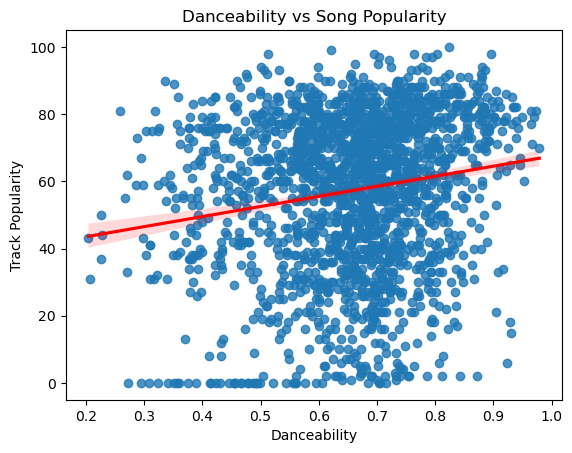

In [17]:
#Plot of Danceability vs Track Popularity

sns.regplot(
    x="DANCEABILITY",
    y="TRACK_POPULARITY",
    data=rq2_df,
    line_kws={"color":"red"}
)

plt.title("Danceability vs Song Popularity")
plt.xlabel("Danceability")
plt.ylabel("Track Popularity")

plt.show()

##### 2.4. Speechiness Visualization

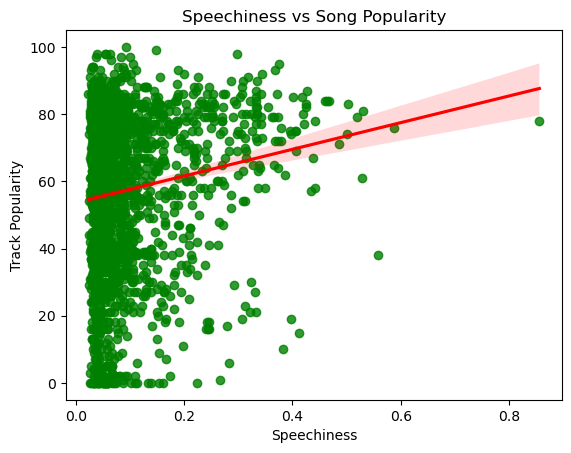

In [18]:
#Plot of Speechiness vs Track Popularity

sns.regplot(
    x="SPEECHINESS",
    y="TRACK_POPULARITY",
    data=rq2_df,
    line_kws={"color":"red"},
    scatter_kws={"color": "green"}
)

plt.title("Speechiness vs Song Popularity")
plt.xlabel("Speechiness")
plt.ylabel("Track Popularity")

plt.show()

##### 2.5. Linear Regression Summary

In [19]:
X = rq2_df[['DANCEABILITY', 'SPEECHINESS']]
y = rq2_df['TRACK_POPULARITY']

# add intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       TRACK_POPULARITY   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     46.31
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           2.20e-20
Time:                        16:54:36   Log-Likelihood:                -9069.7
No. Observations:                2000   AIC:                         1.815e+04
Df Residuals:                    1997   BIC:                         1.816e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           36.7764      2.569     14.314   

#### 3. *How does the average number of charting weeks in Canada differ between songs with danceability and speechiness levels above and below 0.5?*

##### 3.1. Danceability Query

In [20]:
# Query SQL data and put into pandas dataframe 

# 1st audio level: danceability
rq3_danceability = """
SELECT category, AVG(weeks_on_chart) AS avg_weeks_on_chart
FROM (
  SELECT
    weeks_on_chart,
    CASE
      WHEN danceability > 0.5 THEN 'Danceability > 0.5'
      ELSE 'Danceability <= 0.5'
    END AS category
    FROM SPOTIFY_SONGS
    NATURAL JOIN BILLBOARD_WEEKS
)
GROUP BY category
"""

rq3_danceability_df = pd.read_sql(rq3_danceability, connection)
rq3_danceability_df.head()

,CATEGORY,AVG_WEEKS_ON_CHART
0,Danceability <= 0.5,10.473684
1,Danceability > 0.5,12.762590


##### 3.2. Speechiness Query

In [21]:
# 2nd audio level: speechiness
rq3_speechiness = """
SELECT category, AVG(weeks_on_chart) AS avg_weeks_on_chart
FROM (
  SELECT
    weeks_on_chart,
    CASE
      WHEN speechiness > 0.5 THEN 'Speechiness > 0.5'
      ELSE 'Speechiness <= 0.5'
    END AS category
    FROM SPOTIFY_SONGS
    NATURAL JOIN BILLBOARD_WEEKS
)
GROUP BY category
"""

rq3_speechiness_df = pd.read_sql(rq3_speechiness, connection)
rq3_speechiness_df.head()

,CATEGORY,AVG_WEEKS_ON_CHART
0,Speechiness > 0.5,2.500000
1,Speechiness <= 0.5,12.754266


##### 3.3. Danceability Visualization

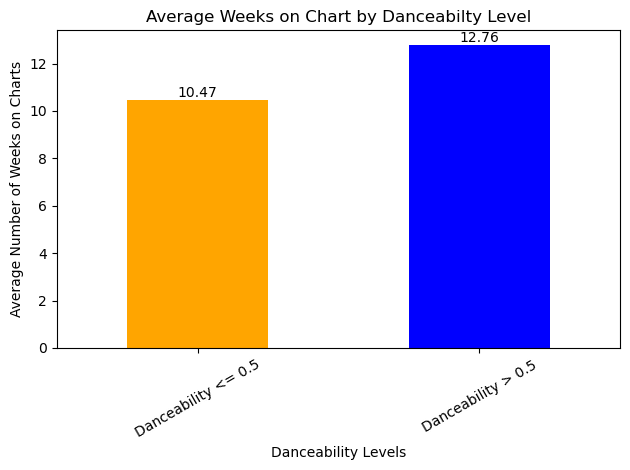

In [22]:
# 1st: danceability 
rq3_1 = rq3_danceability_df.plot(
  x="CATEGORY",
  y="AVG_WEEKS_ON_CHART", 
  kind="bar",
  color=["orange", "blue"],
  legend=False
)

for container in rq3_1.containers:
    rq3_1.bar_label(container, fmt="%.2f")

plt.title("Average Weeks on Chart by Danceabilty Level")
plt.xticks(rotation=30)
plt.xlabel("Danceability Levels")
plt.ylabel("Average Number of Weeks on Charts")
plt.tight_layout()
plt.show()

##### 3.4. Speechiness Visualization

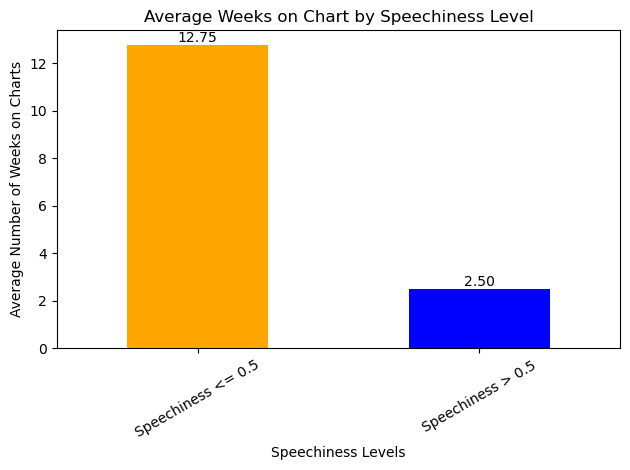

In [23]:
# 2nd: speechiness 
rq3_speechiness_df = rq3_speechiness_df.sort_values("CATEGORY")
rq3_2 = rq3_speechiness_df.plot(
  x="CATEGORY",
  y="AVG_WEEKS_ON_CHART", 
  kind="bar",
  color=["orange", "blue"],
  legend=False
)

for container in rq3_2.containers:
    rq3_2.bar_label(container, fmt="%.2f")

plt.title("Average Weeks on Chart by Speechiness Level")
plt.xticks(rotation=30)
plt.xlabel("Speechiness Levels")
plt.ylabel("Average Number of Weeks on Charts")
plt.tight_layout()
plt.show()

In [24]:
cur.close()
connection.close()